In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
start_scope()

In [3]:
duration = 5 * second
dt_sim = 0.5 * ms
defaultclock.dt = dt_sim
num_neurons = 12

In [4]:
lambda_0 = 5.0 * Hz # Baseline intensity
alpha_exc = 12.0 * Hz # Positive jumps
alpha_inh = -15.0 * Hz # Negative jumps
beta = 10.0 / second # Decay parameter

In [5]:
hawkes_eqs = '''
dh/dt = -beta * h : Hz  # Exponential decay of past event history
lambda_t = clip(lambda_0 + h, 0*Hz, Inf*Hz) : Hz  # Rectified conditional intensity
'''

In [6]:
neurons = NeuronGroup(
    num_neurons, 
    model=hawkes_eqs, 
    threshold='rand() < lambda_t * dt', 
    reset='', # No self-excitation requested; all updates happen via Synapses
    method='euler'
)

In [13]:
# Initialize the history component
neurons.h = 0.0 * Hz

In [8]:
syn = Synapses(neurons, neurons, model='w : Hz', on_pre='h_post += w')
syn.connect(condition='i != j')
# Initialize all weights to zero first
syn.w = 0.0 * Hz

In [9]:
# A forward excitatory ring chain paired with balancing long-range inhibition blocks
weight_matrix = np.zeros((num_neurons, num_neurons))

for i in range(num_neurons):
    # 1. Forward Excitation: Each neuron strongly drives its immediate neighbor
    next_neighbor = (i + 1) % num_neurons
    weight_matrix[i, next_neighbor] = alpha_exc / Hz
    
    # 2. Balancing Cross-Inhibition: Drive localized negative feedback downstream
    inhib_target_1 = (i + 3) % num_neurons
    inhib_target_2 = (i + 4) % num_neurons
    weight_matrix[i, inhib_target_1] = alpha_inh / Hz
    weight_matrix[i, inhib_target_2] = alpha_inh / Hz

# Map our structured numpy matrix back directly into the Brian2 Synapse parameters
syn.w = weight_matrix[syn.i, syn.j] * Hz

![The chain](chain.jpeg)

In [10]:
spike_mon = SpikeMonitor(neurons)
state_mon = StateMonitor(neurons, 'lambda_t', record=True)

In [11]:
run(duration)

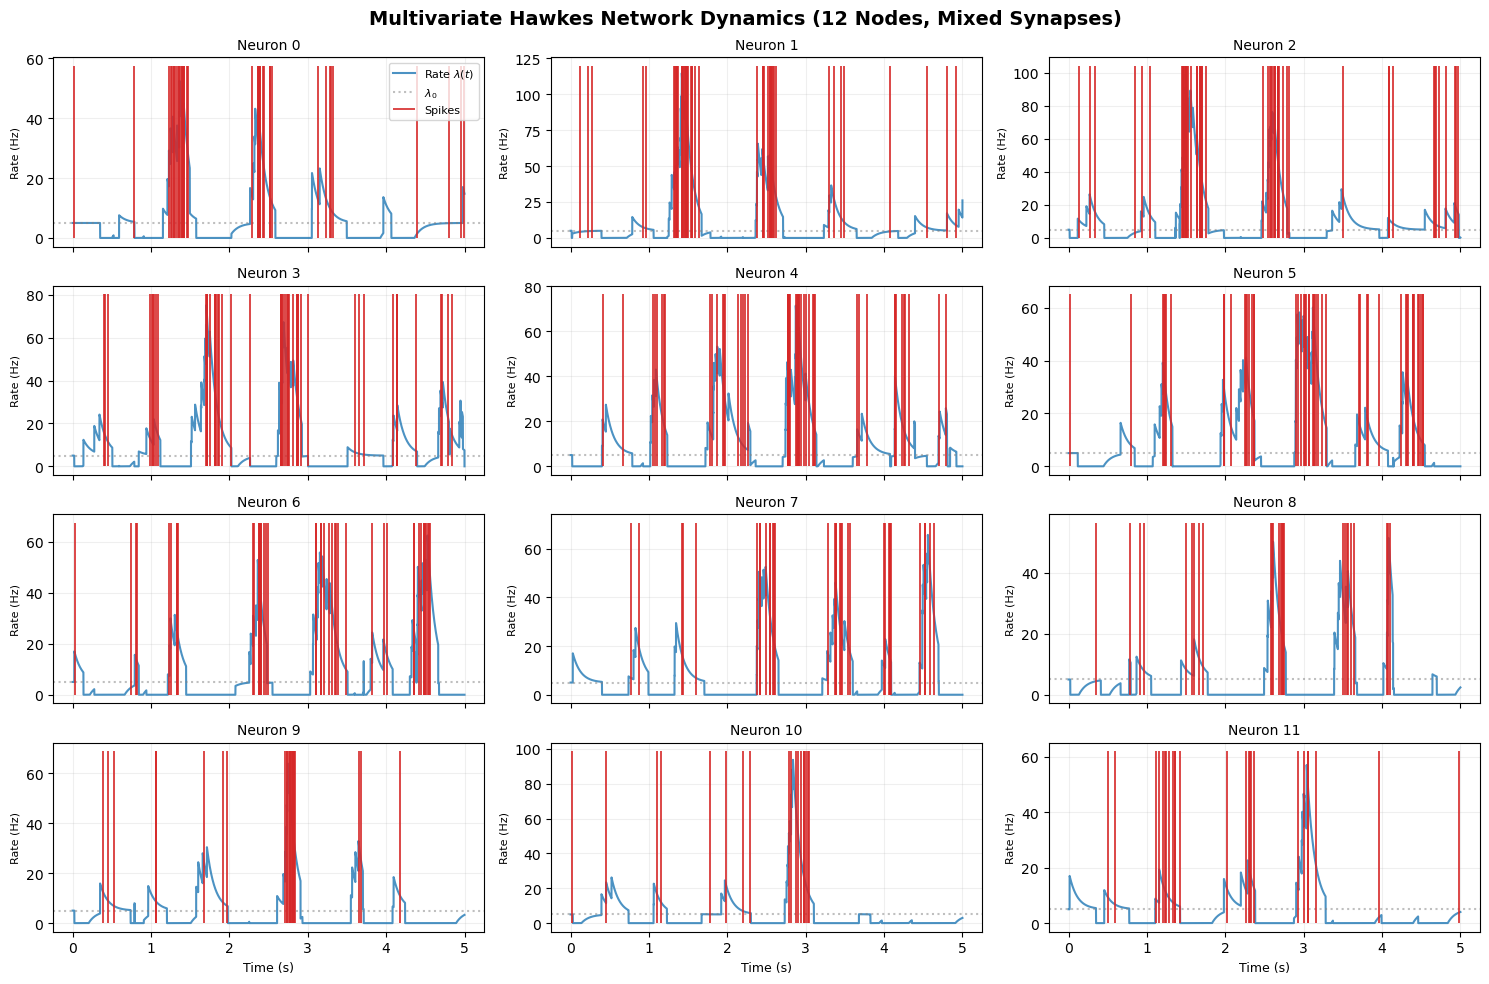

In [12]:
# --- Plotting: 4x3 Grid of Spike Trains and Rates ---
fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharex=True)
axes = axes.flatten()

for idx in range(num_neurons):
    ax = axes[idx]
    
    # Extract data for the specific neuron
    neuron_spikes = spike_mon.t[spike_mon.i == idx] / second
    time_axis = state_mon.t / second
    intensity_profile = state_mon.lambda_t[idx] / Hz
    
    # Plot continuous conditional intensity profile
    ax.plot(time_axis, intensity_profile, color='tab:blue', alpha=0.8, label=r'Rate $\lambda(t)$')
    ax.axhline(lambda_0 / Hz, color='gray', linestyle=':', alpha=0.5, label=r'$\lambda_0$')
    
    # Overlay point process event arrivals as raster ticks
    ax.vlines(neuron_spikes, ymin=0, ymax=max(intensity_profile.max(), lambda_0/Hz) + 5, 
              colors='tab:red', linewidth=1.2, label='Spikes')
    
    # Labeling and aesthetics
    ax.set_title(f'Neuron {idx}', fontsize=10)
    ax.set_ylabel('Rate (Hz)', fontsize=8)
    if idx >= 9:
        ax.set_xlabel('Time (s)', fontsize=9)
    ax.grid(True, alpha=0.2)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Multivariate Hawkes Network Dynamics (12 Nodes, Mixed Synapses)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()